# Daniel's Guide to Quantifying Uncertainty in the Structure Function and Derived Statistics

This uncertainty arises from 
1. Measurement uncertainty
2. Sampling uncertainty
3. Fitting uncertainty

## Next steps
- Tidy code
- Add equations from Overleaf
- Work on real data application

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
# Add .. to the path
import sys

sys.path.append("..")
import src.sf_funcs as sf_funcs

## Bootstrap re-sampling (simulation study)

We want to model the uncertainty under repeated measurement scenarios, and therefore assess the robustness of estimated scaling behaviour: if we were to observe a slightly different interval, how much could the SF differ?.

Bootstrapping is a way to do this that involves re-sampling the original data, with replacement, in order to generate "plausible alternative realisations" of the data. Doing this in blocks preserves (at least the short-range component of) the correlation structure that we need for a time series.

However, we need to be transparent about what properties are being preserved, and what aren't (i.e., long-run correlations.)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Simulate AR(1) time series
np.random.seed(42)
n = 1000
phi = 0.9
noise = np.random.normal(0, 1, n)
ts_sim = np.zeros(n)
for i in range(1, n):
    ts_sim[i] = phi * ts_sim[i - 1] + noise[i]


def block_bootstrap_sf(x, max_lag, block_size, n_bootstraps=1000, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)

    n = len(x)
    n_blocks = n // block_size
    sf_boot = np.zeros((n_bootstraps, max_lag))
    x_boot_all = []

    for b in range(n_bootstraps):
        indices = np.random.randint(0, n_blocks, n_blocks)
        x_boot = np.concatenate(
            [x[i * block_size : (i + 1) * block_size] for i in indices]
        )
        x_boot_all.append(x_boot)
        sf_boot[b] = sf_funcs.compute_sf(
            pd.DataFrame(x_boot), np.arange(1, max_lag + 1), [2], False, False, None
        ).sf_2

    return sf_boot, x_boot_all


# Parameters
max_lag = 50
block_size = 100
n_bootstraps = 100

# Compute original SF and bootstrapped confidence intervals
# For Voyager data
ts = ts_sim

sf_orig = sf_funcs.compute_sf(
    pd.DataFrame(ts), np.arange(1, max_lag+1), [2], False, False, None
)
sf_boot, x_boot = block_bootstrap_sf(ts, max_lag, block_size, n_bootstraps)

In [3]:
def visualize_block_index_mapping(original, boot_samples, block_size, n_samples=2):
    import matplotlib.pyplot as plt
    import numpy as np

    n = len(original)
    n_blocks = n // block_size

    fig, axes = plt.subplots(
        n_samples + 1, 1, figsize=(10, 1.5 * (n_samples + 1)), sharex=True
    )

    # --- Original Time Series ---
    ax0 = axes[0]
    ax0.plot(original, color="black")
    for i in range(n_blocks):
        start = i * block_size
        ax0.axvline(start, linestyle="--", alpha=0.5, color="black")
        ax0.text(
            start + block_size / 2,
            np.max(original) * 0.7,
            f"{i}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )
    ax0.set_title("Original Time Series with Block Indices", fontweight="bold")

    # --- Bootstrapped Samples ---
    for sample_idx in range(n_samples):
        sample = boot_samples[sample_idx]
        ax = axes[sample_idx + 1]

        for i in range(0, len(sample), block_size):
            block = sample[i : i + block_size]

            # Identify origin block
            found_origin = -1
            for j in range(n_blocks):
                orig_block = original[j * block_size : (j + 1) * block_size]
                if np.allclose(block, orig_block, atol=1e-6):
                    found_origin = j
                    break

            ax.plot(range(i, i + len(block)), block, color="black", lw=0.5)
            ax.axvline(i, linestyle="--", alpha=0.7, color="black")
            ax.text(
                i + block_size / 2,
                np.max(sample) * 0.7,
                f"{found_origin}",
                ha="center",
                va="bottom",
                fontsize=9,
            )

        # Add final vertical line for the last block
        ax.axvline(len(sample), linestyle="--", alpha=0.7, color="black")
        ax.set_title(f"Bootstrapped Sample ({sample_idx + 1})")

    plt.tight_layout()
    plt.show()

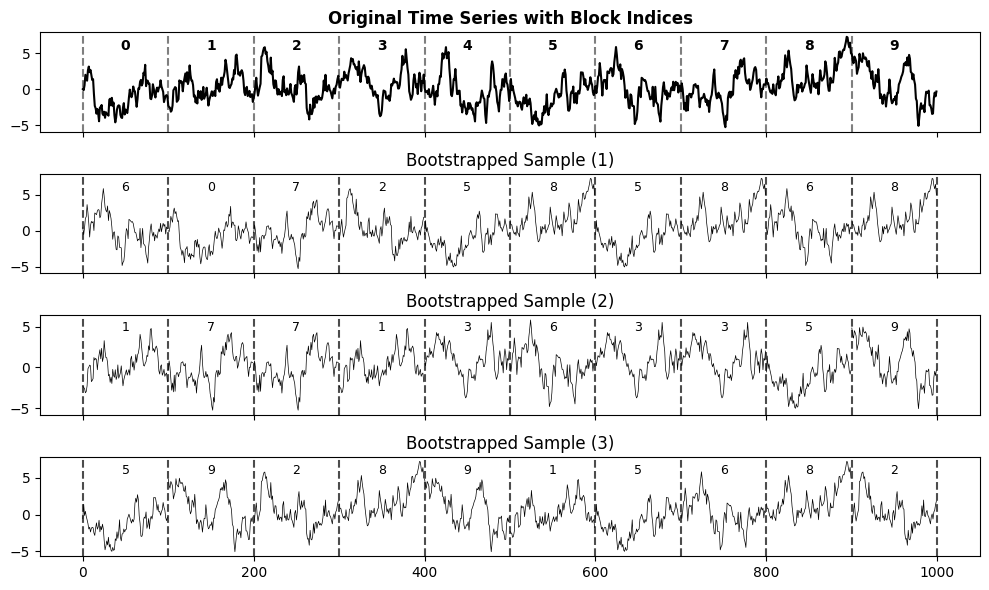

In [4]:
visualize_block_index_mapping(ts_sim, x_boot, block_size, n_samples=3)

Block bootstrapping perserves short-to-intermdiate scale autocorrelations, depending on the blocksize.
We need to make sure 
- the block size is large enough to retain sufficient autocorrelation, i.e., **block size > max lag > $\lambda_C$**
- given this block size, the signal is long enough for many blocks.

Also note, 
- this method will not preserve sharp gradients or bursts, i.e. *intermittency*, unless they're fully contained in blocks.

Overlapping blocks is less 'chunky' and preserves local dependencies somewhat better.

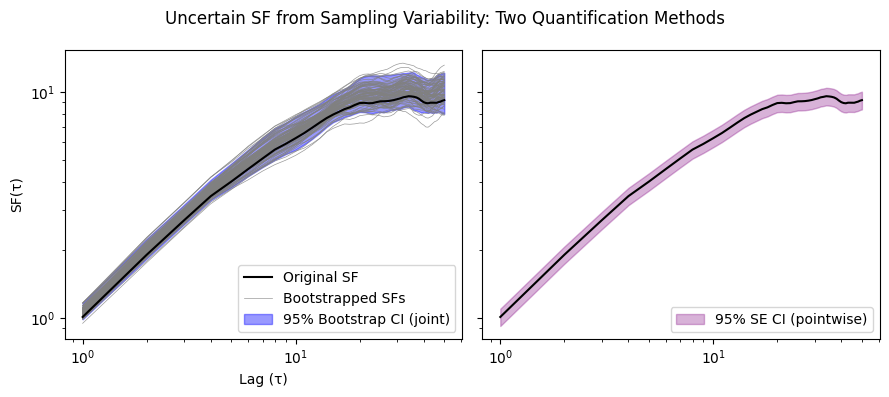

In [5]:
ci_lower = np.percentile(sf_boot, 2.5, axis=0)
ci_upper = np.percentile(sf_boot, 97.5, axis=0)

# Plot
lags = np.arange(1, max_lag + 1)

# Calculate standard error assuming chi-squared approximation (pointwise error bars)
n_pairs = np.array([len(ts) - tau for tau in range(1, max_lag + 1)])
sf_se = sf_orig.sf_2 * np.sqrt(2 / (n_pairs - 1))
ci_se_lower = sf_orig.sf_2 - 1.96 * sf_se
ci_se_upper = sf_orig.sf_2 + 1.96 * sf_se

# Plot with both bootstrap and pointwise SE intervals using fig, ax syntax
fig, ax = plt.subplots(1,2, figsize=(9, 4), sharey=True)
for sf in sf_boot:
    ax[0].plot(lags, sf, color="grey", alpha=0.8, lw=0.5)
ax[0].plot(lags[0], sf_boot[0][0], color="grey", alpha=0.8, lw = 0.5, label="Bootstrapped SFs")
ax[0].plot(lags, sf_orig.sf_2, label="Original SF", color="black")
ax[1].plot(lags, sf_orig.sf_2, color="black")
ax[0].fill_between(
    lags, ci_lower, ci_upper, color="blue", alpha=0.4, label="95% Bootstrap CI (joint)"
)
ax[1].fill_between(
    lags,
    ci_se_lower,
    ci_se_upper,
    color="purple",
    alpha=0.3,
    label="95% SE CI (pointwise)"
)
plt.suptitle("Uncertain SF from Sampling Variability: Two Quantification Methods")
ax[0].set_xlabel("Lag (τ)")
ax[0].set_ylabel("SF(τ)")
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].legend(loc="lower right")

# Fix legend order
handles, labels = ax[0].get_legend_handles_labels()
handles = [handles[1], handles[0], handles[2]]
labels = [labels[1], labels[0], labels[2]]
ax[0].legend(handles, labels, loc="lower right")

fig.tight_layout()
plt.show()

We can see that the bootstrap interval is generally wider, especially at larger lags, reflecting the additional uncertainty due to autocorrelation and non-Gaussianity.

## Artificially add noise

In [6]:
# Block bootstrap implementation
def noise_bootstrap_sf(x, max_lag, sigma, n_bootstraps=1000):
    n = len(x)
    sf_boot = np.zeros((n_bootstraps, max_lag))
    x_boot_all = []

    for b in range(n_bootstraps):
        x_boot = x + np.random.normal(0, sigma, len(x))
        x_boot_all.append(x_boot)
        sf_boot[b] = sf_funcs.compute_sf(
            pd.DataFrame(x_boot), np.arange(1, max_lag + 1), [2], False, False, None
        ).sf_2

    return sf_boot, x_boot_all

# Compute original SF and bootstrapped confidence intervals
# For Voyager data
ts = ts_sim
sigma = 1.0  # Standard deviation of noise

sf_orig = sf_funcs.compute_sf(
    pd.DataFrame(ts), np.arange(1, max_lag + 1), [2], False, False, None
)
sf_boot, x_boot = noise_bootstrap_sf(ts, max_lag, sigma, n_bootstraps)

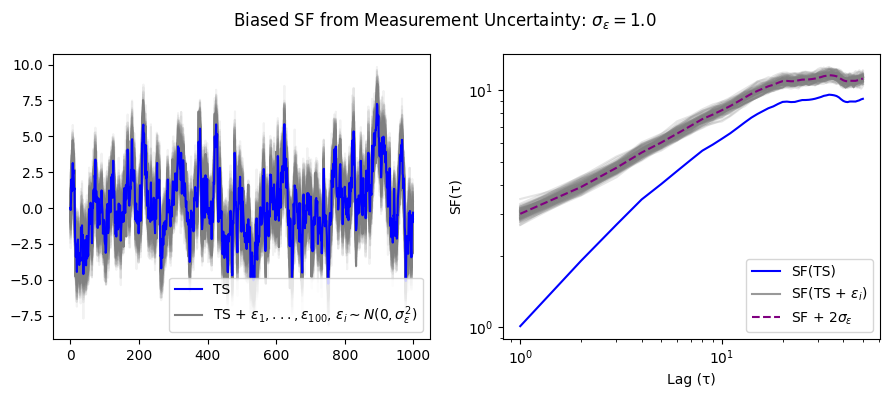

In [12]:
fig, ax = plt.subplots(1,2, figsize=(9, 4))
for i, x in enumerate(x_boot):
    ax[0].plot(x, c="grey", alpha=0.1)
ax[0].plot(
    x_boot[0],
    label=f"TS + $\epsilon_1,...,\epsilon_{{100}}$, $\epsilon_i \sim N(0,\sigma^2_{{\epsilon}})$",
    color="grey",
)
ax[0].plot(ts_sim, label="TS", color="blue")
# Reorder the legend
handles, labels = ax[0].get_legend_handles_labels()
handles = [handles[1], handles[0]]
labels = [labels[1], labels[0]]
ax[0].legend(handles, labels, loc="lower right")
plt.suptitle(f"Biased SF from Measurement Uncertainty: $\sigma_{{\epsilon}}=${sigma}")

ci_lower = np.percentile(sf_boot, 2.5, axis=0)
ci_upper = np.percentile(sf_boot, 97.5, axis=0)

# Plot
lags = np.arange(1, max_lag + 1)

# Plot with both bootstrap and pointwise SE intervals using fig, ax[1] syntax[1]
for sf in sf_boot:
    ax[1].plot(lags, sf, color="grey", alpha=0.2)
ax[1].plot(lags, sf_orig.sf_2, label="SF(TS)", color="blue")
ax[1].plot(lags, sf_boot[0], color="grey", alpha=0.8, label="SF(TS + $\epsilon_i$)")
ax[1].plot(
    lags, sf_orig.sf_2 + 2 * sigma, label="SF + 2$\sigma_{\epsilon}$", color="purple", linestyle="--"
)
ax[1].set_xlabel("Lag (τ)")
ax[1].set_ylabel("SF(τ)")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].legend(loc="lower right")
fig.tight_layout()
plt.show()

## Real data application

- As a demonstration dataset, we'll be working with the some magnetic field data from the Local Interstellar Medium, as measured by Voyager 2. The radial component of this data has particularly large measurement errors.
- NB: Low signal-to-noise ratio for Voyager is making corrected-SF negative. **Try just adding Gaussian noise with given sigma to time series, and run a bootstrap-like model with this. Compare this to corrected values.**

In [8]:
data_full = pd.read_pickle("../data/interim/voyager/voyager1_lism_cleaned.pkl")
data_res = data_full.resample("1D").mean()
data_res.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4146 entries, 2012-08-25 to 2023-12-31
Freq: D
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F1      3969 non-null   float32
 1   BR      3969 non-null   float32
 2   BT      3969 non-null   float32
 3   BN      3969 non-null   float32
dtypes: float32(4)
memory usage: 97.2 KB


Text(0, 0.5, '$B_T$ (nT)')

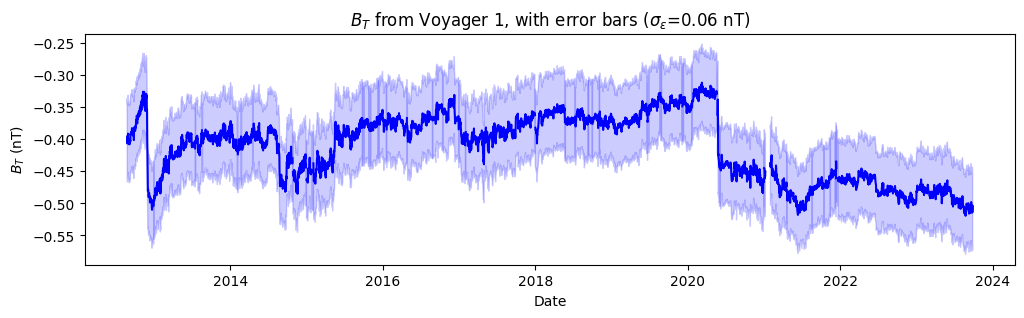

In [9]:
# Plot error bars as shaded region
br_error = 0.06
# Source: Rankin et al. (2023) 

plt.figure(figsize=(12, 3))
plt.plot(data_res.index, data_res["BT"], label="BT", color="blue")
plt.fill_between(
    data_res.index,
    data_res["BT"] - br_error,
    data_res["BT"] + br_error,
    color="blue",
    alpha=0.2,
)
plt.title("$B_T$ from Voyager 1, with error bars ($\sigma_{\epsilon}$=0.06 nT)")
plt.xlabel("Date")
plt.ylabel("$B_T$ (nT)")

## Add noise to Voyager data